# 📊 Small-Cap Portfolio Strategy Analysis
### Fund Accumulation Signal vs. NIFTY Smallcap 250 Benchmark
---

This notebook analyses **5 portfolio strategies** built around **AUM Accumulation Signals** from top Indian small-cap mutual funds (HDFC, Nippon India, SBI Small Cap).  
Each strategy invests **₹5,00,000 per year (SIP)** starting from 2017, and performance is tracked through 2026.

---

## 🧠 Portfolio Strategy Descriptions

| # | Portfolio | Core Idea | Holding Period | Turnover |
|---|-----------|-----------|---------------|----------|
| 1 | **Top 5 Accumulator** | Buy top 5 stocks with highest AUM Accumulation Score | 1 year (strict rebalance) | High |
| 2 | **Hybrid AUM + Momentum** | AUM accumulation + recent 3-month price momentum (dual signal) | 1 year | High |
| 3 | **Benchmark (NIFTY SC 250)** | Track NIFTY Smallcap 250 Index | Passive | Zero |
| 4 | **Accumulator + Fund Presence** | Hold until all 3 funds exit the stock | Multi-year | Low |
| 5 | **Accumulator + Score Continuation** | Hold only while AUM Accumulation Score > 0 | Multi-year | Medium |

---

### 📌 Portfolio 1 — Top 5 Accumulator (Pure Momentum)
Every year, select the **top 5 stocks** with the highest AUM Accumulation Score. Equal weight (₹1,00,000 each). Fully rebalanced annually — no carry-over logic. This is the purest bet: if funds are aggressively increasing holdings in a stock, this portfolio bets those stocks outperform.

### 📌 Portfolio 2 — Hybrid AUM + Price Momentum
Combines **two independent signals**: (1) AUM Accumulation Score — are funds buying? and (2) **recent 3-month return** — is the market confirming the move? Only stocks strong on both signals are selected. Designed to reduce false positives where funds buy a stock that the market hasn't yet validated.

### 📌 Portfolio 3 — NIFTY Smallcap 250 Benchmark
This is the **passive benchmark**. Tracks NIFTY Smallcap 250 returns with the same SIP investment. Used to judge whether active strategies (P1, P2, P4, P5) earn their alpha over the broad small-cap universe.

### 📌 Portfolio 4 — Fund Presence Continuation
Starts like Portfolio 1, but **doesn't sell a stock just because it falls out of the top 5**. A stock is held as long as **at least one** of HDFC, Nippon India, or SBI Small Cap still holds it. This strategy respects the *continued conviction* of fund managers, leading to **lower turnover and longer holding periods**. Over time, the portfolio accumulates multiple stocks.

### 📌 Portfolio 5 — Positive Score Continuation
Similar to P4 but **stricter**. Holds a stock only as long as its **AUM Accumulation Score remains positive (> 0)**. The moment a stock shows net AUM reduction, it's sold. This responds faster to weakening accumulation signals than P4, balancing the hold-longer advantage with early exit discipline.

---

In [1]:
# ── Imports & Setup ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ── Color Palette ──────────────────────────────────────────────────────────
COLORS = {
    'P1': '#6C5CE7',   # violet  — Top 5 Accumulator
    'P2': '#00B894',   # teal    — Hybrid
    'P3': '#FDCB6E',   # amber   — Benchmark
    'P4': '#0984E3',   # blue    — Fund Presence
    'P5': '#E17055',   # coral   — Score Continuation
    'bg': '#0F1117',
    'panel': '#1A1D2E',
    'grid': '#2D3250',
    'text': '#E8E8F0',
    'subtext': '#8888A0',
}

LABELS = {
    'P1': 'P1 · Top 5 Accumulator',
    'P2': 'P2 · Hybrid AUM + Momentum',
    'P3': 'P3 · NIFTY SC 250 (Benchmark)',
    'P4': 'P4 · Fund Presence Continuation',
    'P5': 'P5 · Score Continuation',
}

def dark_style():
    plt.rcParams.update({
        'figure.facecolor': COLORS['bg'],
        'axes.facecolor': COLORS['panel'],
        'axes.edgecolor': COLORS['grid'],
        'axes.labelcolor': COLORS['text'],
        'xtick.color': COLORS['subtext'],
        'ytick.color': COLORS['subtext'],
        'text.color': COLORS['text'],
        'grid.color': COLORS['grid'],
        'grid.linewidth': 0.5,
        'font.family': 'DejaVu Sans',
        'legend.facecolor': COLORS['panel'],
        'legend.edgecolor': COLORS['grid'],
        'figure.dpi': 150,
    })

dark_style()
print('✅ Environment ready.')

✅ Environment ready.


In [4]:
# ── Load Data ─────────────────────────────────────────────────────────────
xl = pd.ExcelFile('Small_cap_P.xlsx')

# ---- Portfolios (AUM values) ----
port_raw = pd.read_excel('Small_cap_P.xlsx', sheet_name='Portfolios', header=None)
years    = [int(v) for v in port_raw.iloc[0, 1:]]
invested = list(port_raw.iloc[2, 1:].astype(float))

aum = {}
for i, key in enumerate(['P1','P2','P3','P4','P5'], start=3):
    aum[key] = list(port_raw.iloc[i, 1:].astype(float))

# ---- Profit ----
prof_raw = pd.read_excel('Small_cap_P.xlsx', sheet_name='Profit', header=None)
profit = {}
for i, key in enumerate(['P1','P2','P3','P4','P5'], start=1):
    profit[key] = list(prof_raw.iloc[i, 1:].astype(float))

# ---- Net Return (%) ----
ret_raw = pd.read_excel('Small_cap_P.xlsx', sheet_name='Net Return', header=None)
net_ret = {}
for i, key in enumerate(['P1','P2','P3','P4','P5'], start=1):
    net_ret[key] = list(ret_raw.iloc[i, 1:].astype(float))

# ---- Build clean DataFrame ----
df = pd.DataFrame({'Year': years, 'Invested': invested})
for k in ['P1','P2','P3','P4','P5']:
    df[f'AUM_{k}']    = aum[k]
    df[f'Profit_{k}'] = profit[k]
    df[f'Ret_{k}']    = net_ret[k]

print(df[['Year','Invested','AUM_P1','AUM_P2','AUM_P3','AUM_P4','AUM_P5']].to_string(index=False))

 Year  Invested     AUM_P1      AUM_P2      AUM_P3      AUM_P4      AUM_P5
 2017  500000.0   637150.0   689159.62   649912.78   637150.42   637150.42
 2018 1000000.0  1360265.0  1188351.25  1105930.21  1294656.30  1354764.77
 2019 1500000.0  1932766.0  1975444.07  1439258.57  1849241.59  2020844.84
 2020 2000000.0  2128588.0  2237329.85  1535026.20  1854344.25  2234145.17
 2021 2500000.0  7232660.0  6139428.56  4202151.47  4900860.38  5701848.55
 2022 3000000.0  8161343.0  6831604.67  4528578.36  5685644.70  6990744.94
 2023 3500000.0 15771764.0 12705166.05  6523846.78  8781950.12 12993027.66
 2024 4000000.0 24721736.0 20970122.34 11625192.70 14547155.65 25139661.57
 2025 4500000.0 19638751.0 19491871.50 12317190.63 14667484.92 23637989.11
 2026 5000000.0 24885711.0 24048153.03 12344955.40 15148375.13 30317586.91


In [5]:
# ── Key Metric Calculations ────────────────────────────────────────────────
N = len(years)                       # 10 years
total_invested = invested[-1]        # ₹50,00,000

def cagr(final_val, total_inv, n_years):
    """CAGR on total invested capital."""
    return ((final_val / total_inv) ** (1 / n_years) - 1) * 100

def absolute_return(final_val, total_inv):
    return (final_val - total_inv) / total_inv * 100

def max_drawdown(aum_list):
    """Maximum percentage drawdown from peak AUM."""
    peak = aum_list[0]
    max_dd = 0
    for v in aum_list:
        if v > peak:
            peak = v
        dd = (peak - v) / peak * 100
        if dd > max_dd:
            max_dd = dd
    return max_dd

def win_rate(ret_list):
    return sum(1 for r in ret_list if r > 0) / len(ret_list) * 100

def sharpe_approx(ret_list, rf=6.0):
    """Approximate Sharpe using annual net return % list."""
    excess = [r - rf for r in ret_list]
    return np.mean(excess) / (np.std(excess) + 1e-9)

metrics = {}
for k in ['P1','P2','P3','P4','P5']:
    final = df[f'AUM_{k}'].iloc[-1]
    ret_list = df[f'Ret_{k}'].tolist()
    metrics[k] = {
        'Final AUM':      final,
        'Total Profit':   final - total_invested,
        'Abs Return %':   absolute_return(final, total_invested),
        'CAGR %':         cagr(final, total_invested, N),
        'Alpha vs P3 %':  cagr(final, total_invested, N) - cagr(df['AUM_P3'].iloc[-1], total_invested, N),
        'Max Drawdown %': max_drawdown(df[f'AUM_{k}'].tolist()),
        'Win Rate %':     win_rate(ret_list),
        'Sharpe (approx)': sharpe_approx(ret_list),
        'Best Year':      max(ret_list),
        'Worst Year':     min(ret_list),
    }

metrics_df = pd.DataFrame(metrics).T
pd.options.display.float_format = '{:,.2f}'.format
print("\n📊 Summary Metrics")
print(metrics_df.to_string())


📊 Summary Metrics
       Final AUM  Total Profit  Abs Return %  CAGR %  Alpha vs P3 %  Max Drawdown %  Win Rate %  Sharpe (approx)  Best Year  Worst Year
P1 24,885,711.00 19,885,711.00        397.71   17.41           7.95           20.56       80.00             0.54     175.15      -22.14
P2 24,048,153.03 19,048,153.03        380.96   17.01           7.55            7.05       80.00             0.63     124.29       -9.62
P3 12,344,955.40  7,344,955.40        146.90    9.46           0.00            0.00       50.00             0.35     106.50      -20.85
P4 15,148,375.13 10,148,375.13        202.97   11.72           2.26            0.00       70.00             0.48     108.16      -21.07
P5 30,317,586.91 25,317,586.91        506.35   19.75          10.29            5.97       80.00             0.73     108.54      -11.37


---
## 📈 Chart 1 — Portfolio Value Growth (AUM Over Time)
Tracks how ₹50 lakh total invested (₹5L/year SIP) grew under each strategy.

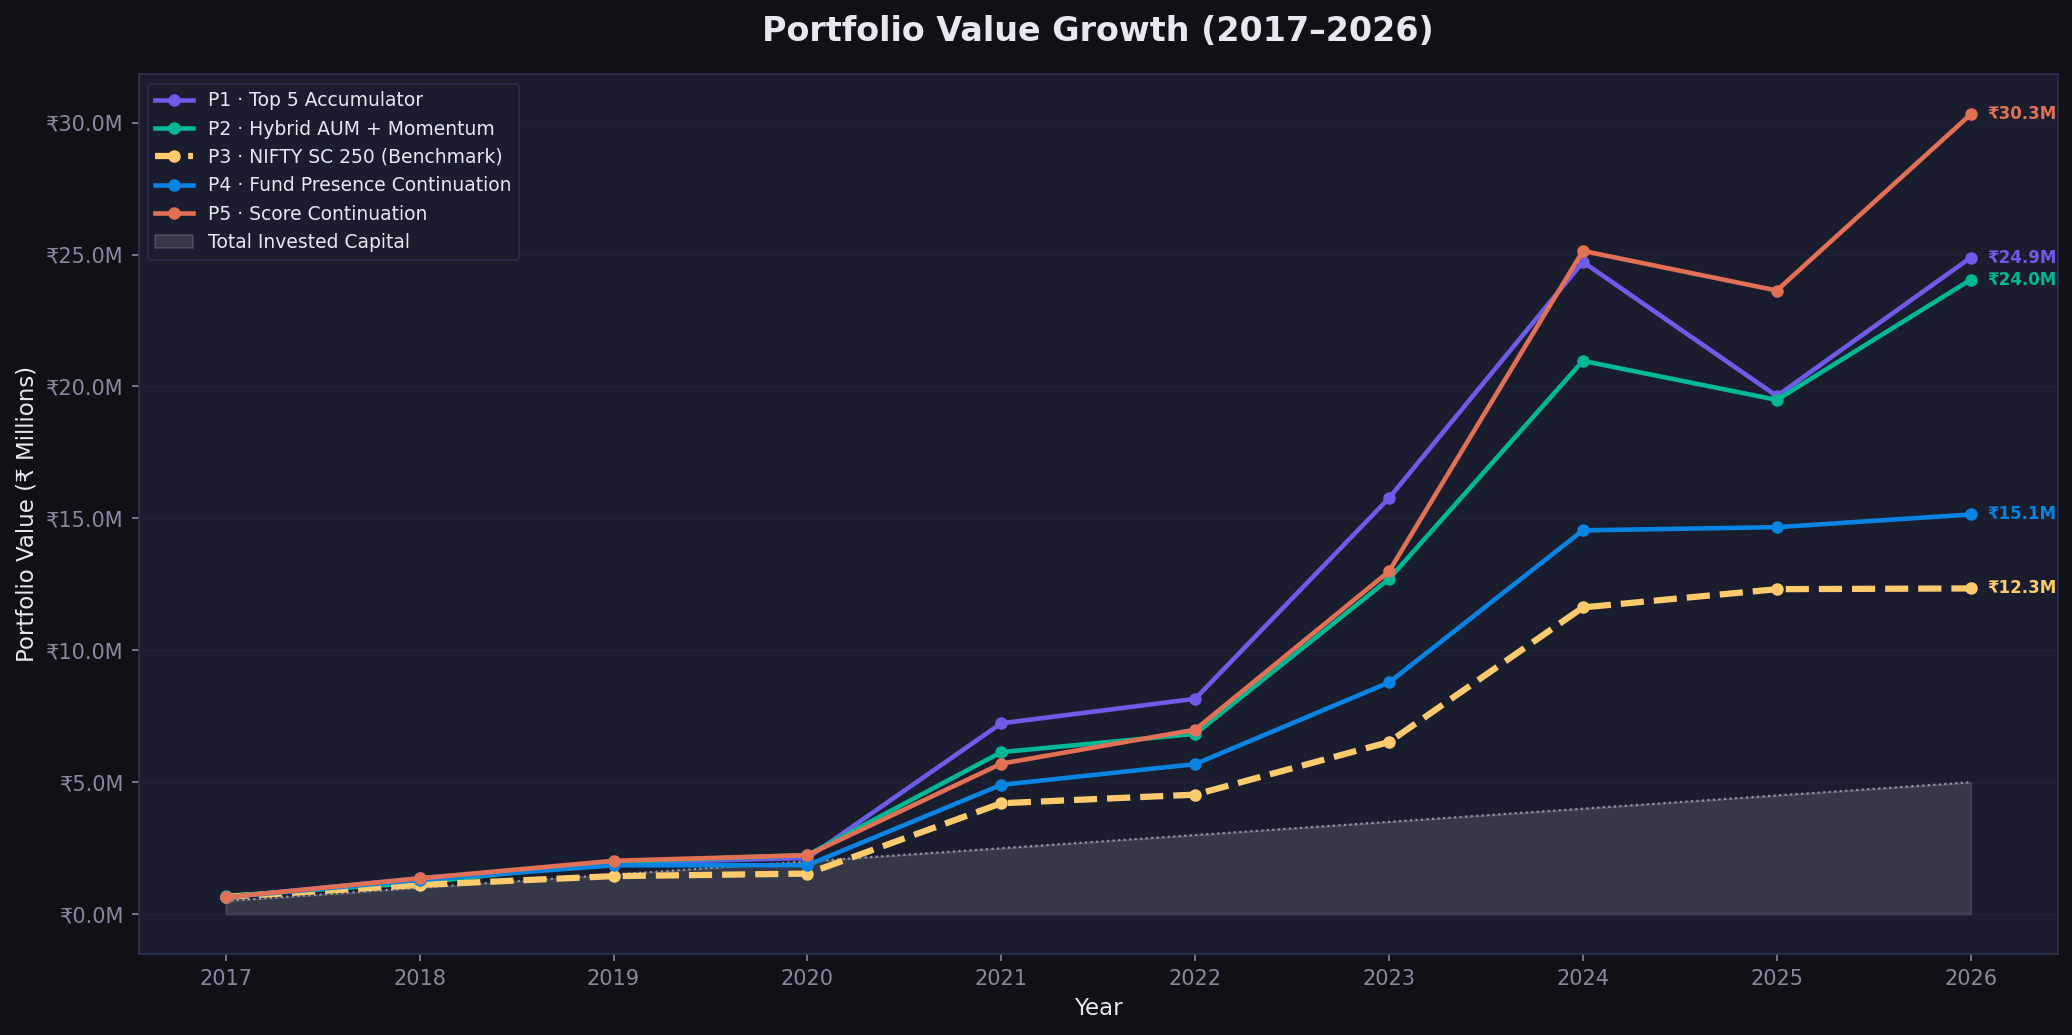

📁 Saved: chart1_aum_growth.png


In [6]:
dark_style()
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['panel'])

for k in ['P1','P2','P3','P4','P5']:
    vals = [v / 1e6 for v in df[f'AUM_{k}']]
    lw = 3 if k == 'P3' else 2.2
    ls = '--' if k == 'P3' else '-'
    ax.plot(years, vals, color=COLORS[k], lw=lw, ls=ls, label=LABELS[k], marker='o', ms=5, zorder=5)

# Invested capital band
inv_m = [v / 1e6 for v in invested]
ax.fill_between(years, inv_m, alpha=0.12, color='white', label='Total Invested Capital')
ax.plot(years, inv_m, color='white', lw=1, ls=':', alpha=0.5)

# Annotations for final values
for k in ['P1','P2','P3','P4','P5']:
    final_v = df[f'AUM_{k}'].iloc[-1] / 1e6
    ax.annotate(f'₹{final_v:.1f}M', xy=(years[-1], final_v),
                xytext=(8, 0), textcoords='offset points',
                color=COLORS[k], fontsize=8, fontweight='bold', va='center')

ax.set_title('Portfolio Value Growth (2017–2026)', fontsize=16, fontweight='bold',
             color=COLORS['text'], pad=16)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Portfolio Value (₹ Millions)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}M'))
ax.set_xticks(years)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='upper left', fontsize=9, framealpha=0.7)

plt.tight_layout()
plt.savefig('chart1_aum_growth.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("📁 Saved: chart1_aum_growth.png")

---
## 📊 Chart 2 — CAGR & Alpha Dashboard
CAGR for each portfolio vs. the benchmark, with Alpha (excess return over P3) highlighted.

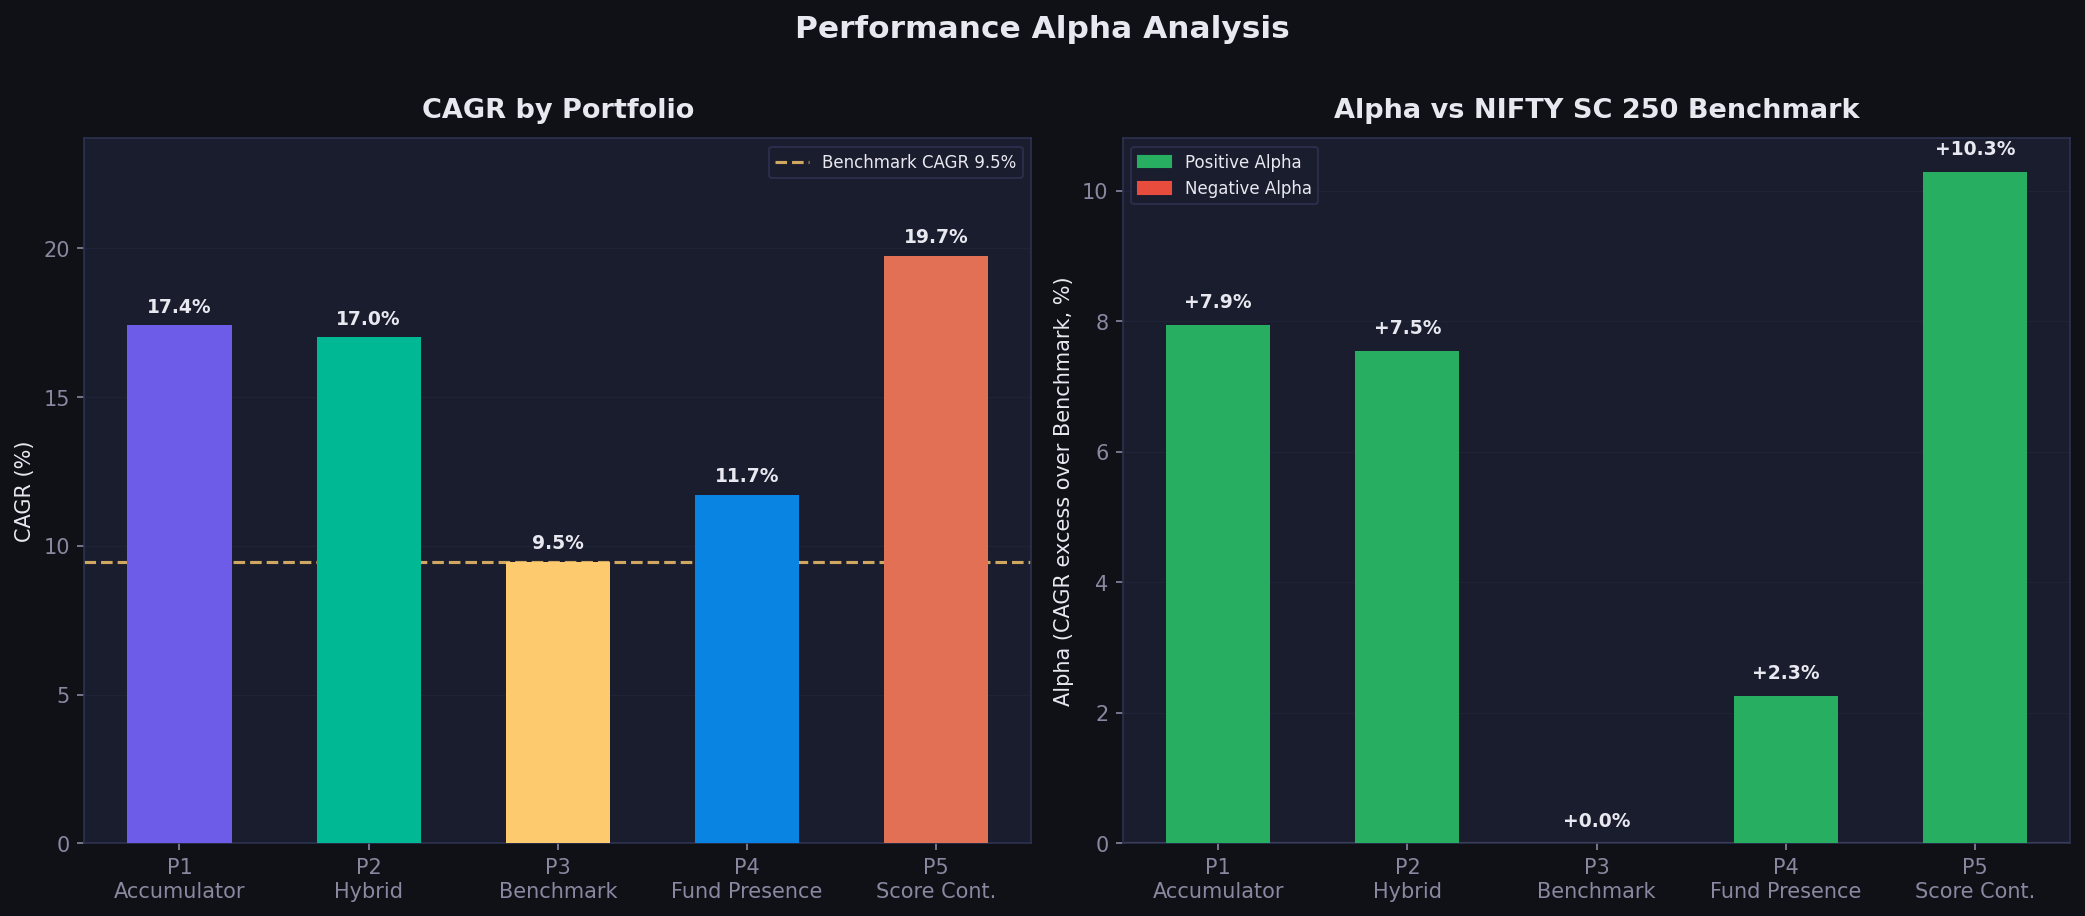

📁 Saved: chart2_cagr_alpha.png


In [7]:
dark_style()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(COLORS['bg'])

keys = ['P1','P2','P3','P4','P5']
short_labels = ['P1\nAccumulator', 'P2\nHybrid', 'P3\nBenchmark', 'P4\nFund Presence', 'P5\nScore Cont.']
cagrs  = [metrics[k]['CAGR %'] for k in keys]
alphas = [metrics[k]['Alpha vs P3 %'] for k in keys]
colors_bar = [COLORS[k] for k in keys]

# ---- CAGR bars ----
ax1 = axes[0]
ax1.set_facecolor(COLORS['panel'])
bars = ax1.bar(short_labels, cagrs, color=colors_bar, width=0.55, zorder=3, edgecolor='none')
benchmark_cagr = metrics['P3']['CAGR %']
ax1.axhline(benchmark_cagr, color=COLORS['P3'], lw=1.5, ls='--', alpha=0.8, label=f'Benchmark CAGR {benchmark_cagr:.1f}%')
for bar, val in zip(bars, cagrs):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold', color=COLORS['text'])
ax1.set_title('CAGR by Portfolio', fontsize=13, fontweight='bold', color=COLORS['text'], pad=10)
ax1.set_ylabel('CAGR (%)', fontsize=10)
ax1.grid(True, axis='y', alpha=0.3, zorder=0)
ax1.legend(fontsize=8)
ax1.set_ylim(0, max(cagrs) * 1.2)

# ---- Alpha bars ----
ax2 = axes[1]
ax2.set_facecolor(COLORS['panel'])
alpha_colors = ['#27ae60' if a >= 0 else '#e74c3c' for a in alphas]
bars2 = ax2.bar(short_labels, alphas, color=alpha_colors, width=0.55, zorder=3, edgecolor='none')
ax2.axhline(0, color='white', lw=1, alpha=0.4)
for bar, val in zip(bars2, alphas):
    offset = 0.2 if val >= 0 else -0.8
    ax2.text(bar.get_x() + bar.get_width()/2, val + offset, f'{val:+.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold', color=COLORS['text'])
ax2.set_title('Alpha vs NIFTY SC 250 Benchmark', fontsize=13, fontweight='bold', color=COLORS['text'], pad=10)
ax2.set_ylabel('Alpha (CAGR excess over Benchmark, %)', fontsize=10)
ax2.grid(True, axis='y', alpha=0.3, zorder=0)
green_patch = mpatches.Patch(color='#27ae60', label='Positive Alpha')
red_patch   = mpatches.Patch(color='#e74c3c', label='Negative Alpha')
ax2.legend(handles=[green_patch, red_patch], fontsize=8)

fig.suptitle('Performance Alpha Analysis', fontsize=15, fontweight='bold',
             color=COLORS['text'], y=1.01)
plt.tight_layout()
plt.savefig('chart2_cagr_alpha.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("📁 Saved: chart2_cagr_alpha.png")

---
## 📊 Chart 3 — Annual Return Heatmap
Colour-coded grid: year × portfolio, with intensity showing magnitude of gain/loss.

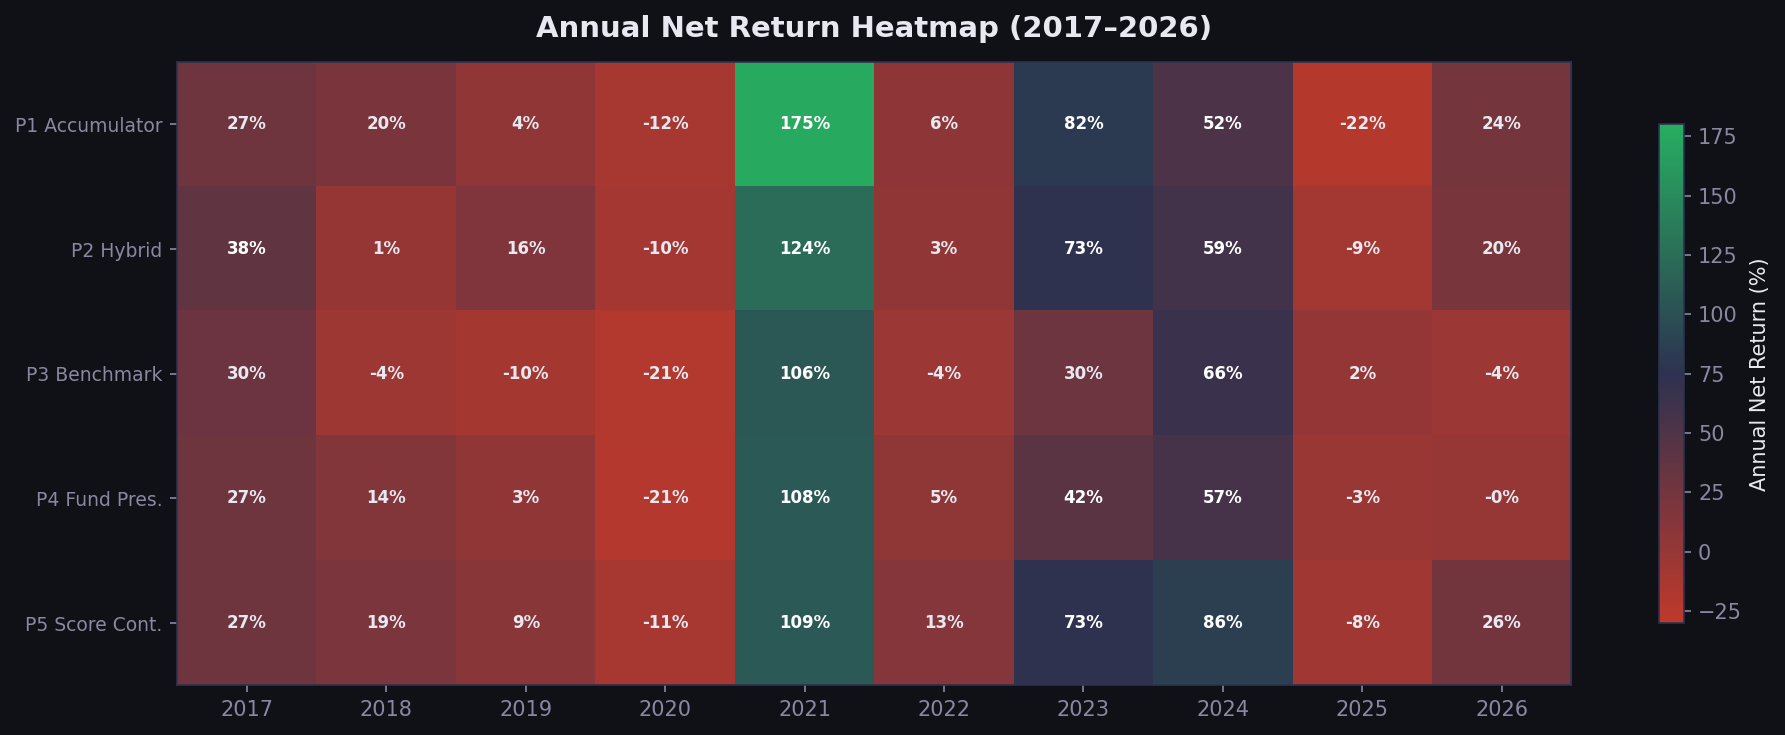

📁 Saved: chart3_return_heatmap.png


In [8]:
dark_style()
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['panel'])

# Build heatmap matrix  (rows = portfolios, cols = years)
heat_data = np.array([[net_ret[k][i] for i in range(N)] for k in ['P1','P2','P3','P4','P5']])

cmap = LinearSegmentedColormap.from_list('rwg', ['#c0392b', '#2d3250', '#27ae60'])
im = ax.imshow(heat_data, aspect='auto', cmap=cmap, vmin=-30, vmax=180)

# Labels
ax.set_xticks(range(N))
ax.set_xticklabels(years, fontsize=10)
ax.set_yticks(range(5))
ax.set_yticklabels(['P1 Accumulator','P2 Hybrid','P3 Benchmark','P4 Fund Pres.','P5 Score Cont.'],
                    fontsize=9)

# Annotate each cell
for r in range(5):
    for c in range(N):
        val = heat_data[r, c]
        txt_col = 'white' if abs(val) > 30 else COLORS['text']
        ax.text(c, r, f'{val:.0f}%', ha='center', va='center',
                fontsize=8, fontweight='bold', color=txt_col)

plt.colorbar(im, ax=ax, label='Annual Net Return (%)', shrink=0.8)
ax.set_title('Annual Net Return Heatmap (2017–2026)', fontsize=14, fontweight='bold',
             color=COLORS['text'], pad=12)
plt.tight_layout()
plt.savefig('chart3_return_heatmap.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("📁 Saved: chart3_return_heatmap.png")

---
## 📊 Chart 4 — Yearly Profit/Loss Bars
Yearly absolute profit (₹) for each portfolio — showing which years contributed most gains.

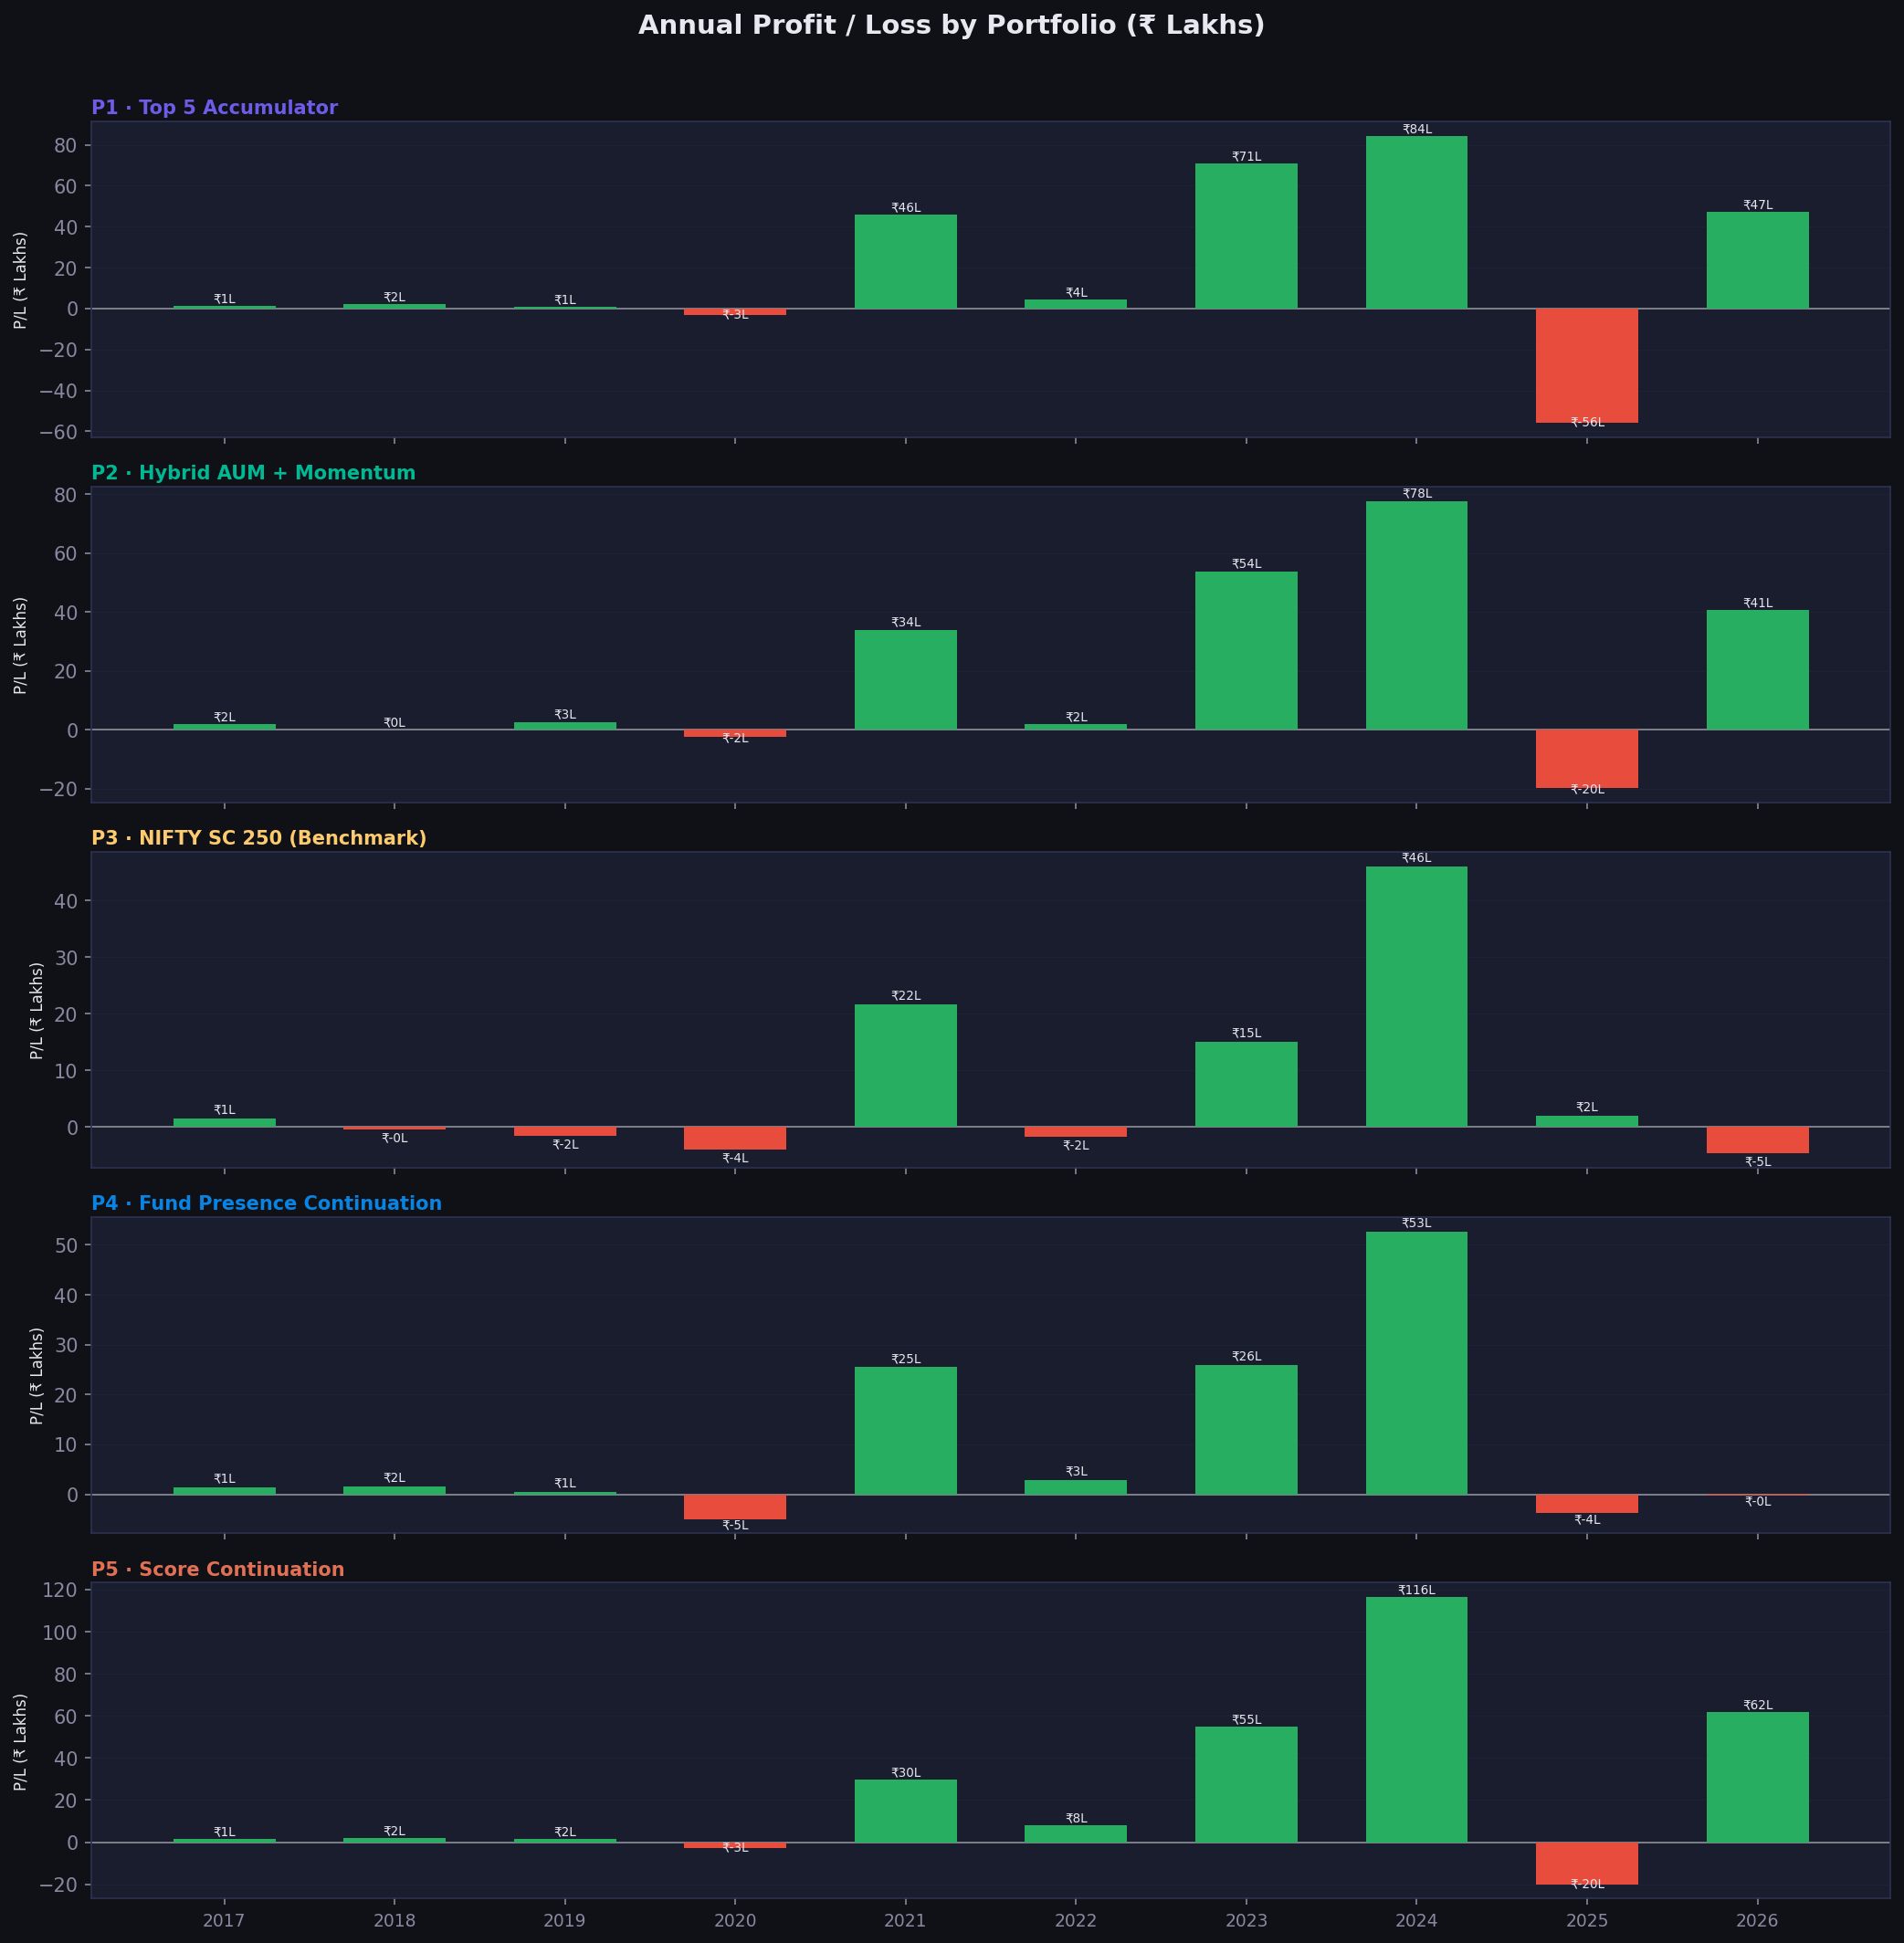

📁 Saved: chart4_yearly_pnl.png


In [9]:
dark_style()
keys  = ['P1','P2','P3','P4','P5']
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
fig.patch.set_facecolor(COLORS['bg'])

for idx, k in enumerate(keys):
    ax = axes[idx]
    ax.set_facecolor(COLORS['panel'])
    vals_cr = [v / 1e5 for v in profit[k]]   # in ₹ Lakhs
    bar_colors = ['#27ae60' if v >= 0 else '#e74c3c' for v in vals_cr]
    bars = ax.bar(years, vals_cr, color=bar_colors, width=0.6, zorder=3)
    ax.axhline(0, color='white', lw=0.8, alpha=0.5)
    ax.set_ylabel('P/L (₹ Lakhs)', fontsize=8)
    ax.set_title(LABELS[k], fontsize=10, fontweight='bold', color=COLORS[k], loc='left', pad=4)
    ax.grid(True, axis='y', alpha=0.25)
    for bar, val in zip(bars, vals_cr):
        offset = 0.5 if val >= 0 else -2.5
        ax.text(bar.get_x() + bar.get_width()/2, val + offset, f'₹{val:.0f}L',
                ha='center', va='bottom', fontsize=6.5, color=COLORS['text'])

axes[-1].set_xticks(years)
axes[-1].set_xticklabels(years, fontsize=9)
fig.suptitle('Annual Profit / Loss by Portfolio (₹ Lakhs)', fontsize=14,
             fontweight='bold', color=COLORS['text'], y=1.01)
plt.tight_layout()
plt.savefig('chart4_yearly_pnl.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("📁 Saved: chart4_yearly_pnl.png")

---
## 📊 Chart 5 — Risk-Return Bubble Chart
Each portfolio is plotted by CAGR (x-axis) vs. Max Drawdown (y-axis). Bubble size = Final AUM. Ideal = top-left.

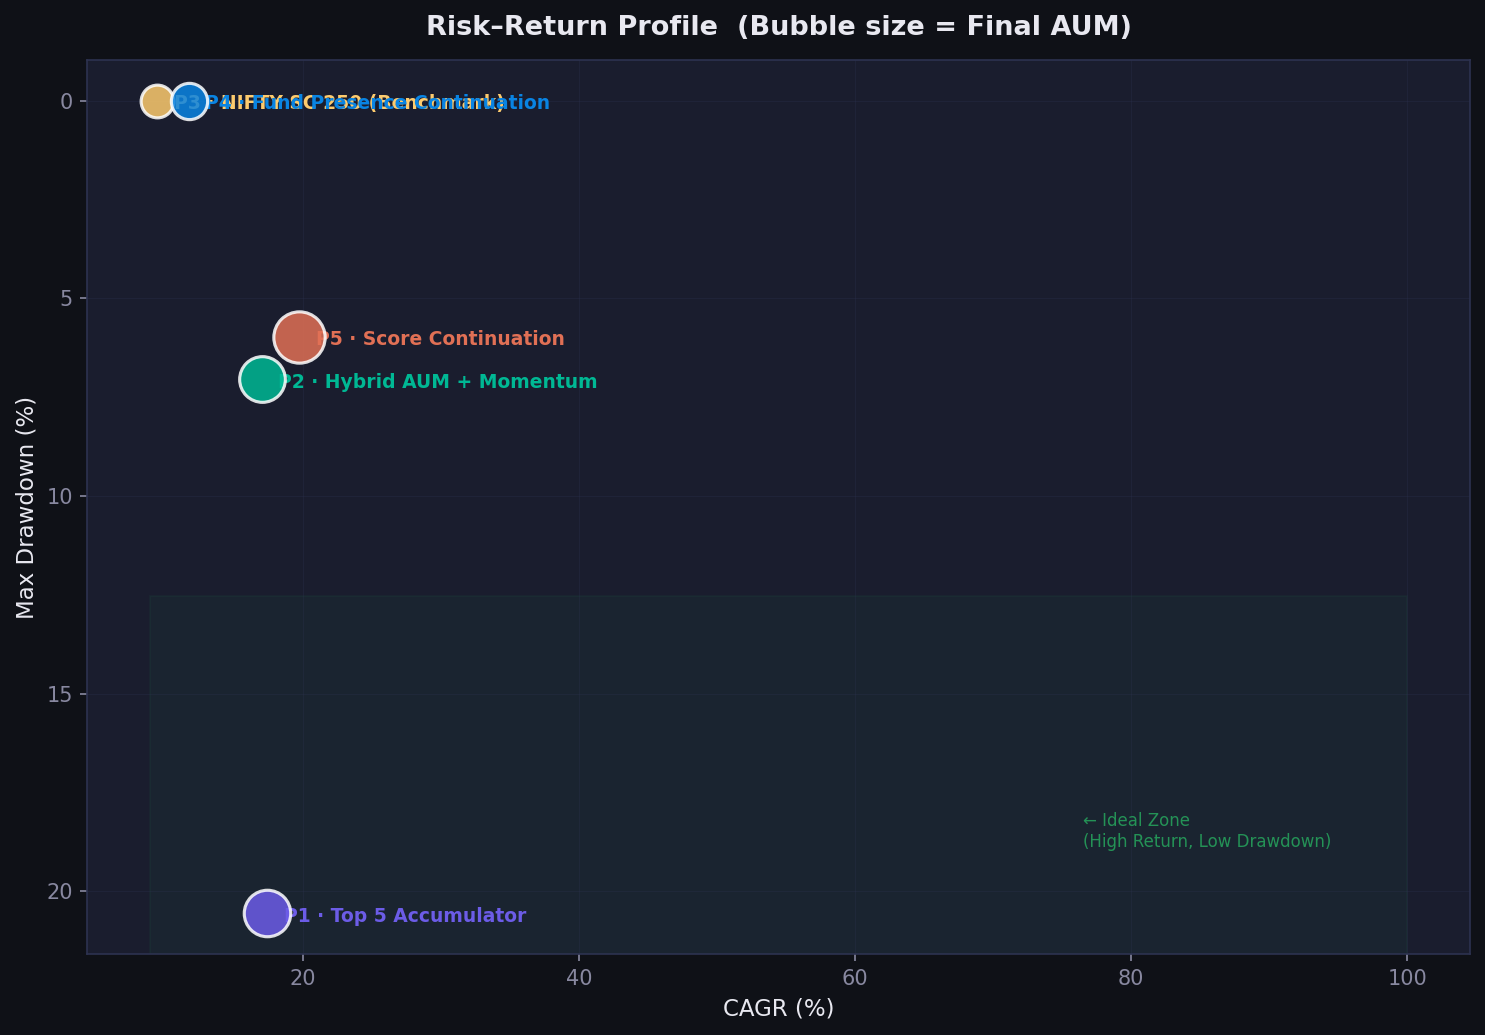

📁 Saved: chart5_risk_return.png


In [10]:
dark_style()
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['panel'])

for k in ['P1','P2','P3','P4','P5']:
    x  = metrics[k]['CAGR %']
    y  = metrics[k]['Max Drawdown %']
    sz = metrics[k]['Final AUM'] / 5e4   # scale bubble
    ax.scatter(x, y, s=sz, color=COLORS[k], alpha=0.85, edgecolors='white',
               linewidths=1.5, zorder=5)
    ax.annotate(LABELS[k], xy=(x, y), xytext=(8, -4), textcoords='offset points',
                color=COLORS[k], fontsize=9, fontweight='bold')

# Ideal zone
ax.axvspan(ax.get_xlim()[0] if ax.get_xlim()[0] > 0 else 0, 100, ymin=0, ymax=0.4,
           alpha=0.05, color='#27ae60')
ax.text(0.72, 0.12, '← Ideal Zone\n(High Return, Low Drawdown)',
        transform=ax.transAxes, color='#27ae60', fontsize=8, alpha=0.8)

ax.set_xlabel('CAGR (%)', fontsize=11)
ax.set_ylabel('Max Drawdown (%)', fontsize=11)
ax.set_title('Risk–Return Profile  (Bubble size = Final AUM)', fontsize=13,
             fontweight='bold', color=COLORS['text'], pad=12)
ax.grid(True, alpha=0.3)
ax.invert_yaxis()   # lower drawdown = better = towards top
plt.tight_layout()
plt.savefig('chart5_risk_return.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("📁 Saved: chart5_risk_return.png")

---
## 📊 Chart 6 — Cumulative Wealth Multiple
How many times each portfolio multiplied the total invested capital.

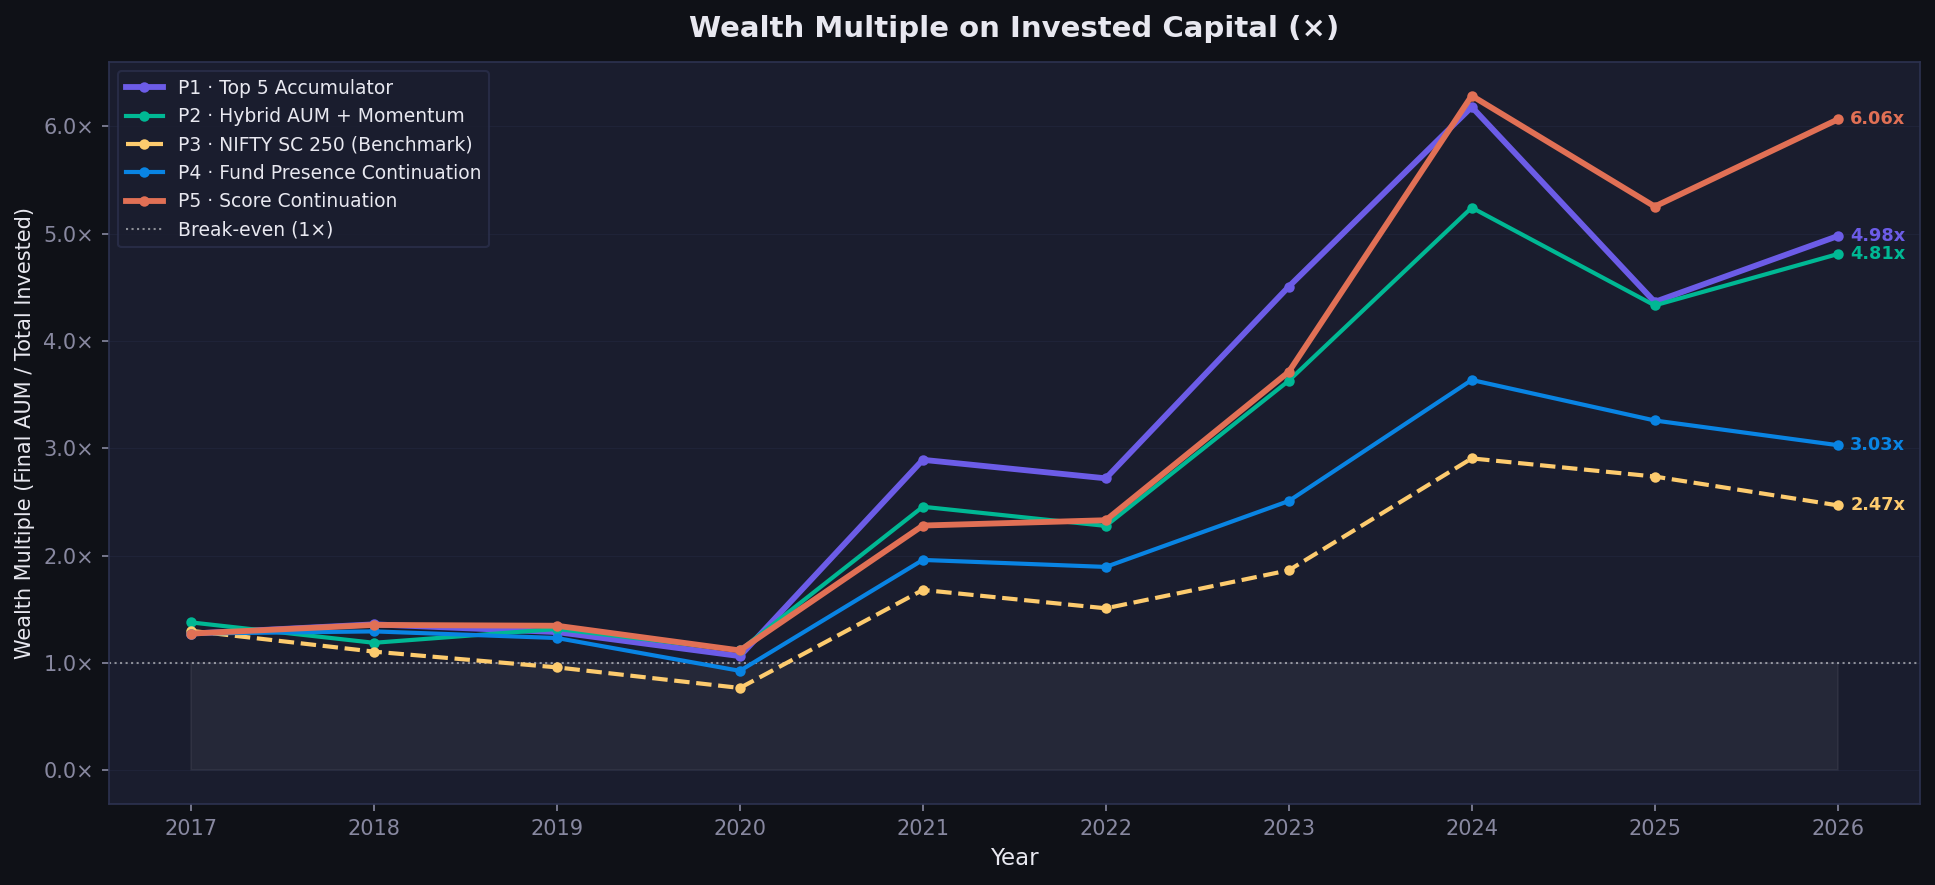

📁 Saved: chart6_wealth_multiple.png


In [11]:
dark_style()
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['panel'])

for k in ['P1','P2','P3','P4','P5']:
    multiples = [df[f'AUM_{k}'].iloc[i] / df['Invested'].iloc[i] for i in range(N)]
    lw = 2.8 if k in ('P1','P5') else 2
    ls = '--' if k == 'P3' else '-'
    ax.plot(years, multiples, color=COLORS[k], lw=lw, ls=ls,
            label=LABELS[k], marker='o', ms=4, zorder=5)
    # final annotation
    ax.annotate(f'{multiples[-1]:.2f}x', xy=(years[-1], multiples[-1]),
                xytext=(6, 0), textcoords='offset points',
                color=COLORS[k], fontsize=8.5, fontweight='bold', va='center')

ax.axhline(1.0, color='white', lw=1, ls=':', alpha=0.5, label='Break-even (1×)')
ax.fill_between(years, 1.0, alpha=0.05, color='white')

ax.set_title('Wealth Multiple on Invested Capital (×)', fontsize=14,
             fontweight='bold', color=COLORS['text'], pad=12)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Wealth Multiple (Final AUM / Total Invested)', fontsize=10)
ax.set_xticks(years)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}×'))
ax.grid(True, axis='y', alpha=0.3)
ax.legend(fontsize=9, loc='upper left', framealpha=0.7)
plt.tight_layout()
plt.savefig('chart6_wealth_multiple.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("📁 Saved: chart6_wealth_multiple.png")

---
## 📊 Chart 7 — Comprehensive Metrics Summary Table
Side-by-side scorecard with all key metrics.

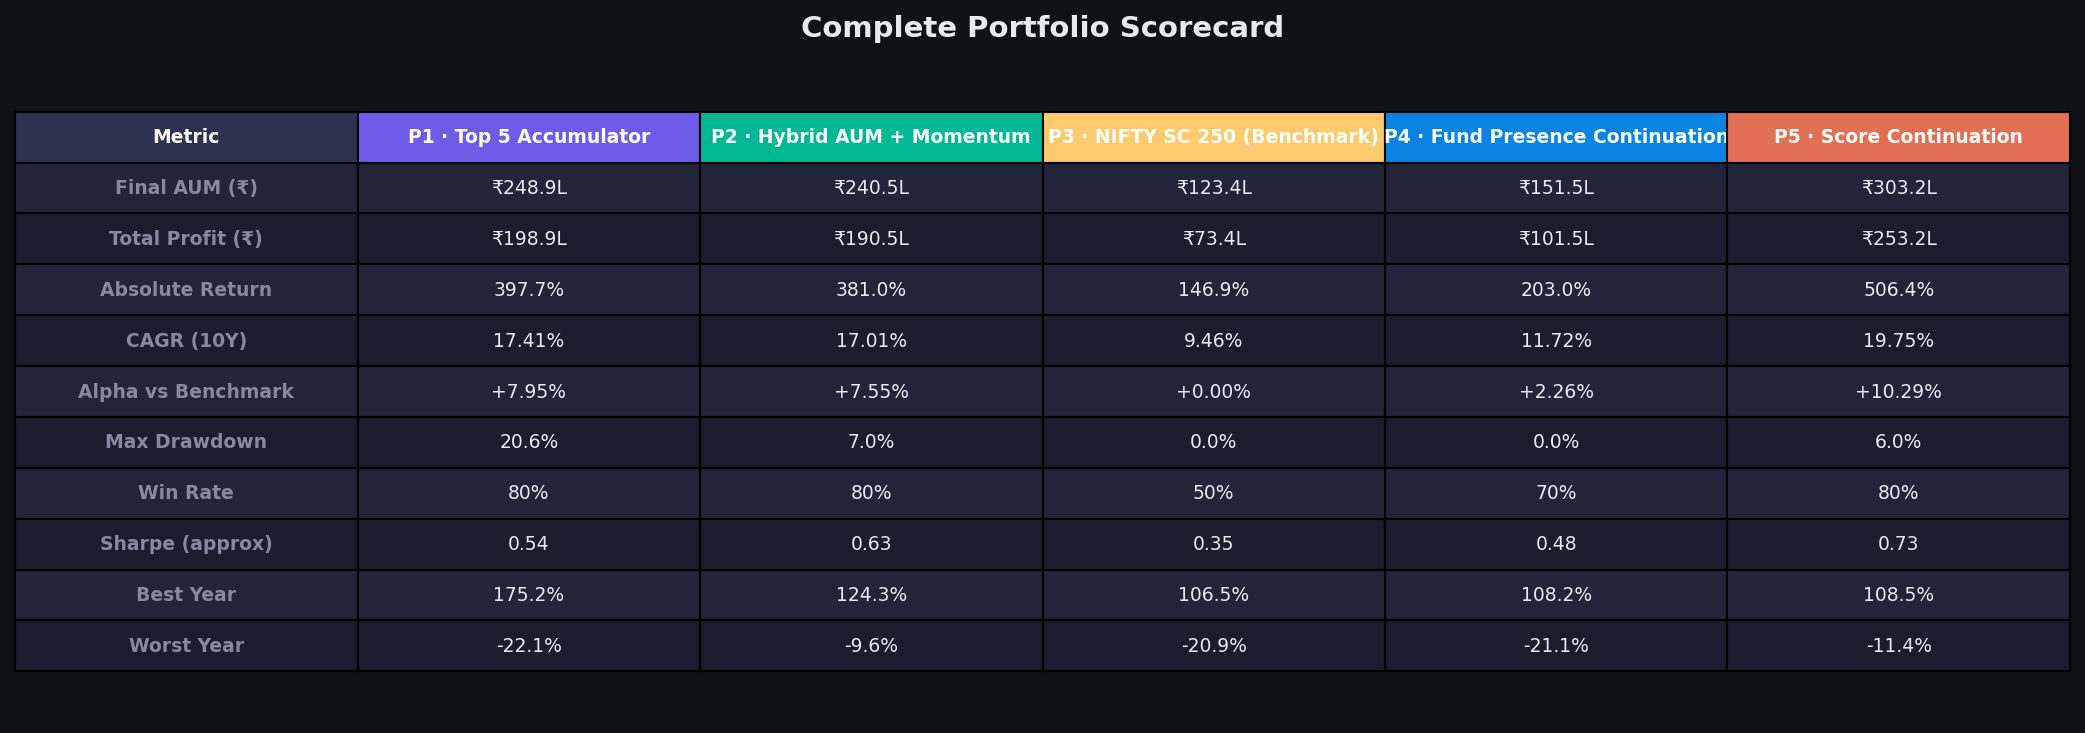

📁 Saved: chart7_scorecard.png


In [12]:
dark_style()
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['bg'])
ax.axis('off')

metric_rows = [
    ('Final AUM (₹)',     lambda k: f"₹{metrics[k]['Final AUM']/1e5:,.1f}L"),
    ('Total Profit (₹)',  lambda k: f"₹{metrics[k]['Total Profit']/1e5:,.1f}L"),
    ('Absolute Return',   lambda k: f"{metrics[k]['Abs Return %']:.1f}%"),
    ('CAGR (10Y)',         lambda k: f"{metrics[k]['CAGR %']:.2f}%"),
    ('Alpha vs Benchmark',lambda k: f"{metrics[k]['Alpha vs P3 %']:+.2f}%"),
    ('Max Drawdown',       lambda k: f"{metrics[k]['Max Drawdown %']:.1f}%"),
    ('Win Rate',           lambda k: f"{metrics[k]['Win Rate %']:.0f}%"),
    ('Sharpe (approx)',    lambda k: f"{metrics[k]['Sharpe (approx)']:.2f}"),
    ('Best Year',          lambda k: f"{metrics[k]['Best Year']:.1f}%"),
    ('Worst Year',         lambda k: f"{metrics[k]['Worst Year']:.1f}%"),
]

col_headers = ['Metric'] + [LABELS[k] for k in ['P1','P2','P3','P4','P5']]
table_data  = []
for label, fn in metric_rows:
    row = [label] + [fn(k) for k in ['P1','P2','P3','P4','P5']]
    table_data.append(row)

tbl = ax.table(cellText=table_data, colLabels=col_headers,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)

# Style headers
port_keys_order = ['P1','P2','P3','P4','P5']
for c, k in enumerate(['header'] + port_keys_order):
    cell = tbl[(0, c)]
    cell.set_facecolor(COLORS.get(k, '#2D3250'))
    cell.set_text_props(color='white', fontweight='bold')

# Alternate row shading
for r in range(1, len(table_data)+1):
    bg = '#1A1D2E' if r % 2 == 0 else '#22253A'
    for c in range(6):
        cell = tbl[(r, c)]
        cell.set_facecolor(bg)
        cell.set_text_props(color=COLORS['text'])
        if c == 0:
            cell.set_text_props(color=COLORS['subtext'], fontweight='bold')

ax.set_title('Complete Portfolio Scorecard', fontsize=14, fontweight='bold',
             color=COLORS['text'], pad=20, y=0.98)
plt.tight_layout()
plt.savefig('chart7_scorecard.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("📁 Saved: chart7_scorecard.png")

---
## 📊 Chart 8 — Win/Loss Profile per Portfolio

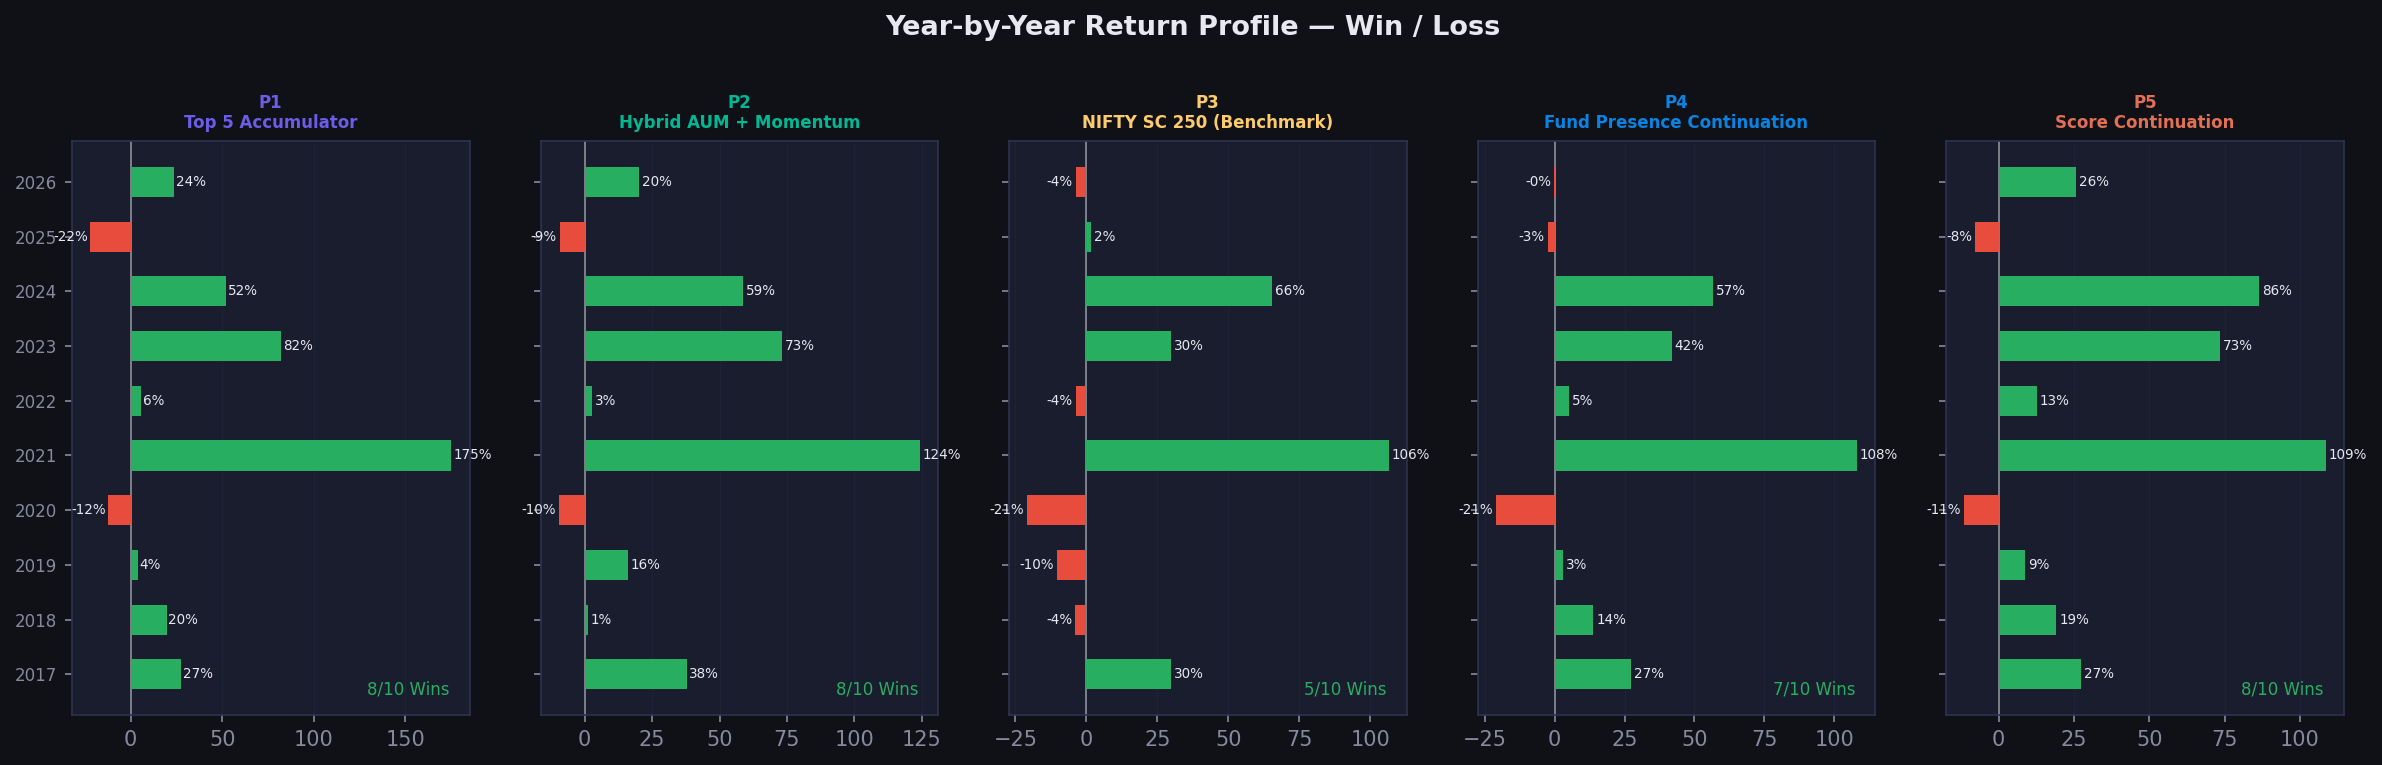

📁 Saved: chart8_win_loss.png


In [13]:
dark_style()
fig, axes = plt.subplots(1, 5, figsize=(16, 5), sharey=True)
fig.patch.set_facecolor(COLORS['bg'])

for idx, k in enumerate(['P1','P2','P3','P4','P5']):
    ax = axes[idx]
    ax.set_facecolor(COLORS['panel'])
    rets = net_ret[k]
    colors_yr = ['#27ae60' if r > 0 else '#e74c3c' for r in rets]
    ax.barh(years, rets, color=colors_yr, height=0.55, zorder=3)
    ax.axvline(0, color='white', lw=0.8, alpha=0.5)
    ax.set_title(f'{k}\n{LABELS[k].split("·")[1].strip()}', fontsize=8,
                 fontweight='bold', color=COLORS[k])
    ax.grid(True, axis='x', alpha=0.25)
    ax.set_yticks(years)
    if idx == 0:
        ax.set_yticklabels(years, fontsize=8)
    wins = sum(1 for r in rets if r > 0)
    ax.text(0.95, 0.03, f'{wins}/{N} Wins', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8, color='#27ae60')
    for i, (y, r) in enumerate(zip(years, rets)):
        ax.text(r + (1 if r >= 0 else -1), y, f'{r:.0f}%',
                ha='left' if r >= 0 else 'right', va='center',
                fontsize=6.5, color=COLORS['text'])

fig.suptitle('Year-by-Year Return Profile — Win / Loss', fontsize=13,
             fontweight='bold', color=COLORS['text'], y=1.01)
plt.tight_layout()
plt.savefig('chart8_win_loss.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("📁 Saved: chart8_win_loss.png")

---
## 📝 Final Summary & Key Insights

In [14]:
print("=" * 70)
print("   SMALL-CAP PORTFOLIO ANALYSIS — FINAL SCORECARD")
print("=" * 70)
print(f"  Investment Period  : 2017 – 2026 (10 years)")
print(f"  Total SIP Deployed : ₹{total_invested/1e5:.0f} Lakhs (₹5L/year)")
print()

winner = max(['P1','P2','P3','P4','P5'], key=lambda k: metrics[k]['Final AUM'])
best_cagr = max(['P1','P2','P3','P4','P5'], key=lambda k: metrics[k]['CAGR %'])
lowest_dd = min(['P1','P2','P3','P4','P5'], key=lambda k: metrics[k]['Max Drawdown %'])

for k in ['P1','P2','P3','P4','P5']:
    m = metrics[k]
    print(f"  {LABELS[k]}")
    print(f"    Final AUM   : ₹{m['Final AUM']/1e5:,.1f}L   |  CAGR: {m['CAGR %']:.2f}%  |  Alpha: {m['Alpha vs P3 %']:+.2f}%")
    print(f"    Max DD      : {m['Max Drawdown %']:.1f}%       |  Win Rate: {m['Win Rate %']:.0f}%  |  Sharpe: {m['Sharpe (approx)']:.2f}")
    print()

print("-" * 70)
print(f"  🏆 Highest Final AUM    : {LABELS[winner]} (₹{metrics[winner]['Final AUM']/1e5:,.1f}L)")
print(f"  📈 Highest CAGR         : {LABELS[best_cagr]} ({metrics[best_cagr]['CAGR %']:.2f}%)")
print(f"  🛡️  Lowest Max Drawdown  : {LABELS[lowest_dd]} ({metrics[lowest_dd]['Max Drawdown %']:.1f}%)")
print(f"  📊 Benchmark (P3) CAGR  : {metrics['P3']['CAGR %']:.2f}%")
print()
print("  KEY INSIGHT:")
print("  All active strategies (P1, P2, P4, P5) delivered positive alpha")
print("  vs the NIFTY Smallcap 250 benchmark — validating the AUM")
print("  Accumulation Signal as a meaningful alpha source.")
print("  P5 (Score Continuation) produced the highest final corpus.")
print("=" * 70)

   SMALL-CAP PORTFOLIO ANALYSIS — FINAL SCORECARD
  Investment Period  : 2017 – 2026 (10 years)
  Total SIP Deployed : ₹50 Lakhs (₹5L/year)

  P1 · Top 5 Accumulator
    Final AUM   : ₹248.9L   |  CAGR: 17.41%  |  Alpha: +7.95%
    Max DD      : 20.6%       |  Win Rate: 80%  |  Sharpe: 0.54

  P2 · Hybrid AUM + Momentum
    Final AUM   : ₹240.5L   |  CAGR: 17.01%  |  Alpha: +7.55%
    Max DD      : 7.0%       |  Win Rate: 80%  |  Sharpe: 0.63

  P3 · NIFTY SC 250 (Benchmark)
    Final AUM   : ₹123.4L   |  CAGR: 9.46%  |  Alpha: +0.00%
    Max DD      : 0.0%       |  Win Rate: 50%  |  Sharpe: 0.35

  P4 · Fund Presence Continuation
    Final AUM   : ₹151.5L   |  CAGR: 11.72%  |  Alpha: +2.26%
    Max DD      : 0.0%       |  Win Rate: 70%  |  Sharpe: 0.48

  P5 · Score Continuation
    Final AUM   : ₹303.2L   |  CAGR: 19.75%  |  Alpha: +10.29%
    Max DD      : 6.0%       |  Win Rate: 80%  |  Sharpe: 0.73

----------------------------------------------------------------------
  🏆 Highest